[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## UE 2.3 Time Shifting and Time Mirroring of Signals

We clarify how to interpret time shifting and time mirroring of a signal $x(t)$ towards $x(-t + t_\text{Shift})$

In [1]:
import sympy as sp
sp.init_printing()
t = sp.symbols('t', real=True)
MirrorAxis = sp.Symbol('MirrorAxis', real=True)
# test signals to be shifted and mirrored
if False:  # special case with no heaviside shift and toffs = 0 to start with
    xref = sp.exp(-t*3) * sp.Heaviside(t)
    toffs = 0  # delayed for >0, leading for <0
    tshift = 1  # delayed for >0, leading for <0
    ymax = 1
elif False:  # case with all different numbers, to see general behaviour
    xref = sp.exp(-t*3) * sp.Heaviside(t+5/4)
    toffs = 2  # delayed for >0, leading for <0
    tshift = 1  # delayed for >0, leading for <0
    ymax = 50
else:  # case for taks FBE36B0684 in sig_sys_ex_02.tex
    xref = sp.exp(-t) * sp.Heaviside(t)
    toffs = -1  # delayed for >0, leading for <0
    tshift = 3  # delayed for >0, leading for <0
    ymax = 1

## Method A: 1st Mirror, 2nd Shift

* blue: original signal
* red: mirrored signal
* green: mirrored and shifted signal, final result

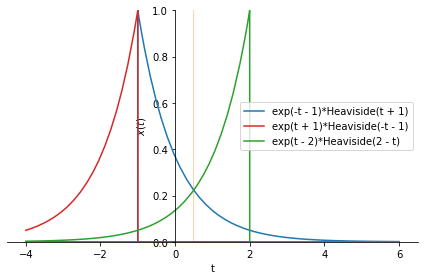

In [2]:
x1 = xref.subs(t, +(t - toffs))
x = xref.subs(t,  -(t - toffs))
x2 = xref.subs(t, -(t - toffs - tshift))

px1 = sp.plot(x1, (t, -4, 6), ylim=[0, ymax], ylabel='$x(t)$',
              line_color='C0', legend=' ', show=False)
px = sp.plot(x, (t, -4, 6), ylim=[0, ymax], ylabel='$x(t)$',
             line_color='C3', legend=' ', show=False)
px2 = sp.plot(x2, (t, -4, 6), ylim=[0, ymax], ylabel='$x(t)$',
              line_color='C2', legend=' ', show=False)
pma = sp.plot_implicit(sp.Eq(MirrorAxis, toffs+tshift/2),
                       line_color='C1', legend=' ', show=False)

px1.extend(px)
px1.extend(px2)
px1.extend(pma)
px1.show()

In [3]:
toffs  # time at which the mirror axis occurs for blue vs. red

## Method B: 1st Shift, 2nd Mirror

* blue: original signal
* red: shifted signal (delayed, i.e. shift to the right for $t_\text{Shift}>0$; leading, i.e. shift to the left for $t_\text{Shift}<0$)
* green: shifted and mirrored (along vertical axis at $t = t_\text{Offset} + t_\text{Shift}$) signal, final result

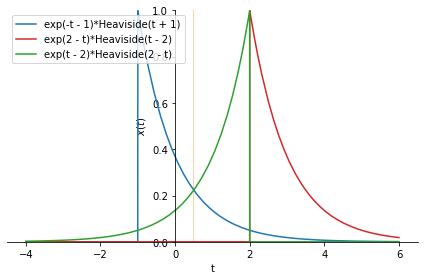

In [4]:
x1 = xref.subs(t, +(t - toffs))
x = xref.subs(t,  +(t - toffs - tshift))
x2 = xref.subs(t, -(t - toffs - tshift))

px1 = sp.plot(x1, (t, -4, 6), ylim=[0, ymax], ylabel='$x(t)$',
              line_color='C0', legend=' ', show=False)
px = sp.plot(x, (t, -4, 6), ylim=[0, ymax], ylabel='$x(t)$',
             line_color='C3', legend=' ', show=False)
px2 = sp.plot(x2, (t, -4, 6), ylim=[0, ymax], ylabel='$x(t)$',
              line_color='C2', legend=' ', show=False)
pma = sp.plot_implicit(sp.Eq(MirrorAxis, toffs+tshift/2),
                       line_color='C1', legend=' ', show=False)

px1.extend(px)
px1.extend(px2)
px1.extend(pma)
px1.show()

In [5]:
toffs + tshift  # time at which the mirror axis occurs for red vs. green

## Method C: direct

$x(t)$ can be directly mirrored along the vertical axis $t = t_\text{Offset} + \frac{t_\text{Shift}}{2}$. See the orange vertical mirroring axis in the plots for method A and B.

In [6]:
toffs + tshift/2  # time at which the mirror axis occurs for blue vs. green
# this is the orange line in both plots above!

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.